In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("C://Users//SI Ddhu//Desktop//Customer_Churn_Analytics_Dataset.xlsx")
df



,Customer_ID,Age,Gender,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Payment_Method,Support_Tickets,Churn
0,CUST1000,56,Male,20,4374.81,15080.88,Quarterly,UPI,2,No
1,CUST1001,46,Female,25,1487.80,129800.58,Quarterly,UPI,5,Yes
2,CUST1002,32,Male,4,4885.46,48816.73,Yearly,Credit Card,2,No
3,CUST1003,25,Male,10,4008.91,40102.04,Quarterly,UPI,4,No
4,CUST1004,38,Male,3,1014.07,22268.34,Monthly,Debit Card,6,Yes
...,...,...,...,...,...,...,...,...,...,...
495,CUST1495,56,Female,37,2929.58,96712.22,Monthly,Credit Card,6,No
496,CUST1496,49,Female,38,653.84,102899.79,Yearly,Credit Card,4,No
497,CUST1497,41,Male,30,4940.12,29319.24,Yearly,Credit Card,4,No
498,CUST1498,40,Male,9,1053.37,80148.30,Quarterly,Net Banking,8,No


Basic Data Understanding

In [6]:

df.shape


(500, 10)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      500 non-null    object 
 1   Age              500 non-null    int64  
 2   Gender           500 non-null    object 
 3   Tenure_Months    500 non-null    int64  
 4   Monthly_Charges  500 non-null    float64
 5   Total_Charges    500 non-null    float64
 6   Contract_Type    500 non-null    object 
 7   Payment_Method   500 non-null    object 
 8   Support_Tickets  500 non-null    int64  
 9   Churn            500 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 39.2+ KB


In [8]:
df.describe()


,Age,Tenure_Months,Monthly_Charges,Total_Charges,Support_Tickets
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,39.326000,29.488000,2785.376840,101303.742460,4.55200
std,12.200386,17.136428,1305.766225,54921.380251,2.86071
min,18.000000,1.000000,501.070000,5064.840000,0.00000
25%,29.000000,14.000000,1665.090000,52584.805000,2.00000
50%,41.000000,30.000000,2843.215000,103295.380000,5.00000
75%,50.000000,44.250000,3876.332500,149664.855000,7.00000
max,59.000000,59.000000,4997.090000,199118.700000,9.00000


Check Missing Values

In [9]:
df.isnull().sum()


Customer_ID        0
Age                0
Gender             0
Tenure_Months      0
Monthly_Charges    0
Total_Charges      0
Contract_Type      0
Payment_Method     0
Support_Tickets    0
Churn              0
dtype: int64

Data Cleaning & Formatting

In [13]:

categorical_cols = ['Gender', 'Contract_Type', 'Payment_Method', 'Churn']

for col in categorical_cols:
    df[col] = df[col].astype('category')

df.dtypes


Customer_ID          object
Age                   int64
Gender             category
Tenure_Months         int64
Monthly_Charges     float64
Total_Charges       float64
Contract_Type      category
Payment_Method     category
Support_Tickets       int64
Churn              category
Churn_Flag         category
Revenue_Loss        float64
dtype: object

Key Business Metrics

In [21]:
df['Churn_Flag'] = df['Churn_Flag'].astype(int)


In [22]:
df[['Churn', 'Churn_Flag']].dtypes


Churn         category
Churn_Flag       int64
dtype: object

In [23]:
total_customers = len(df)
churned_customers = df['Churn_Flag'].sum()

churn_rate = round((churned_customers / total_customers) * 100, 2)

total_customers, churn_rate


(500, np.float64(24.2))

Churn Analysis (EDA)

📊 Churn Distribution

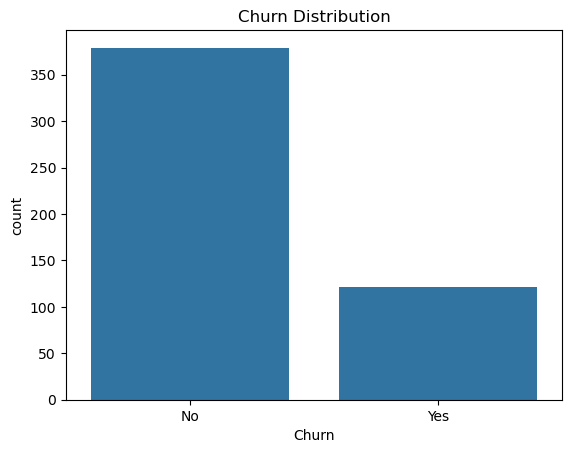

In [24]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()


📊 Churn by Contract Type

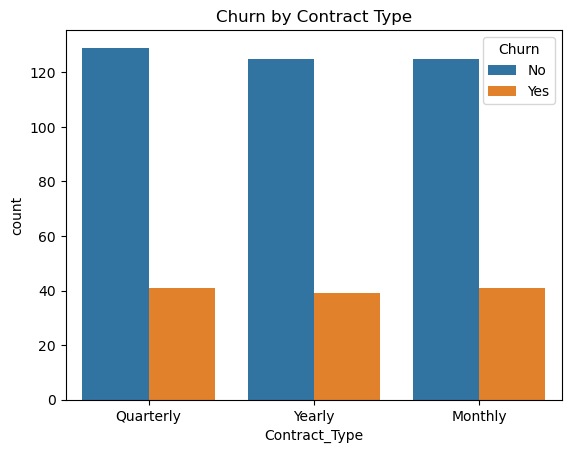

In [26]:
sns.countplot(x='Contract_Type', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()


📊 Churn by Tenure

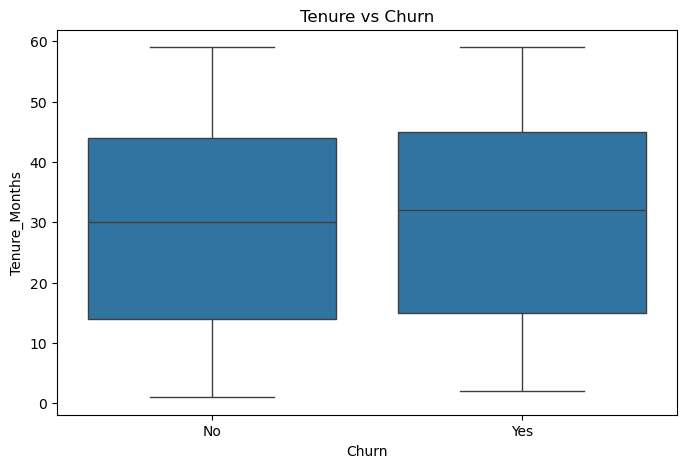

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Tenure_Months', data=df)
plt.title("Tenure vs Churn")
plt.show()


📊 Monthly Charges vs Churn

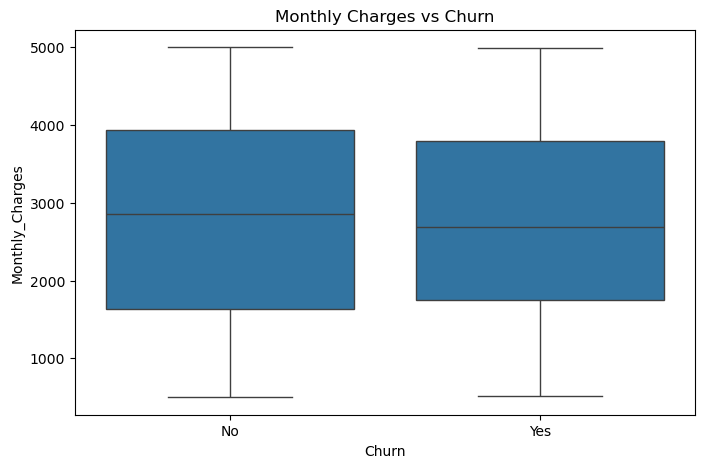

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Monthly_Charges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


📊 Revenue Loss by Contract Type

df['Revenue_Loss'] = np.where(
    df['Churn'] == 'Yes',
    df['Monthly_Charges'],
    0
)
df


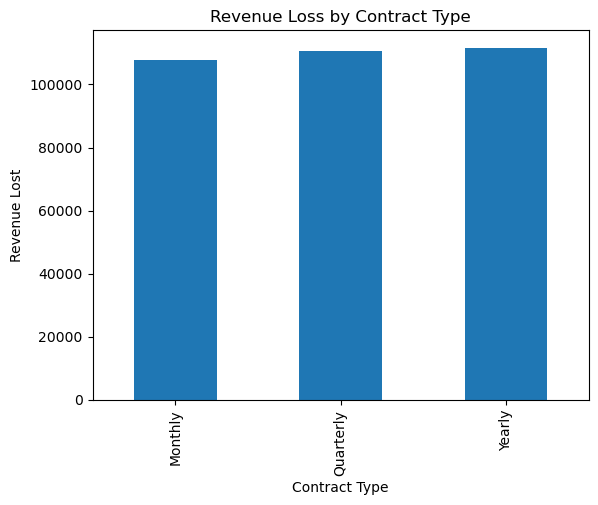

In [31]:
df.groupby('Contract_Type')['Revenue_Loss'].sum().plot(kind='bar')

plt.title("Revenue Loss by Contract Type")
plt.ylabel("Revenue Lost")
plt.xlabel("Contract Type")
plt.show()


Correlation Analysis

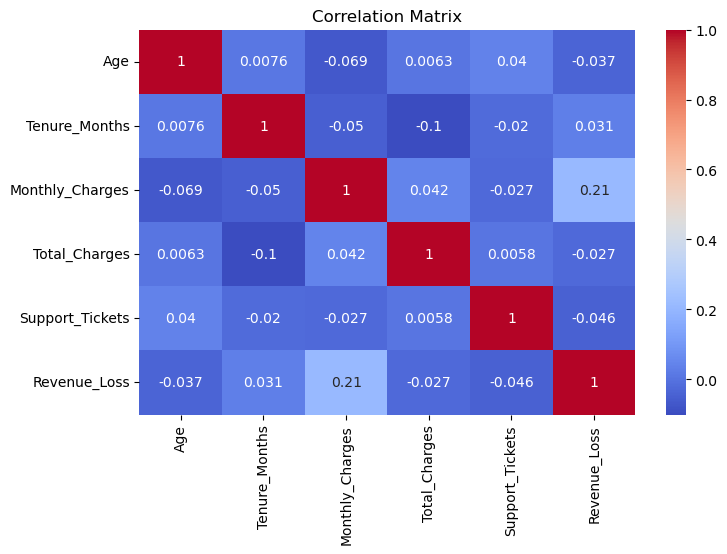

In [34]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


Business Insights

In [35]:
df.groupby('Churn')[['Monthly_Charges', 'Tenure_Months', 'Support_Tickets']].mean()


,Monthly_Charges,Tenure_Months,Support_Tickets
Churn,,,
No,2803.377282,29.034301,4.638522
Yes,2728.995289,30.909091,4.280992
